## Canonical Codes

In [1]:
import sys, os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from my_models import TwoLayerNet, batch_mask_loader
from common.optimizer import *
from common.util import smooth_curve


np.random.seed(42)

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)


epoch = 10
eval_per_step = 600
train_size = x_train.shape[0]
batch_size = 200
learning_rate = 0.01

network = TwoLayerNet(784, 50, 10)

TypeError: can only concatenate list (not "int") to list

In [70]:
optimizers_dict = {
    'SGD': SGD(lr=learning_rate),
    'Momentum': Momentum(lr=learning_rate),
    'AdaGrad': AdaGrad(lr=learning_rate),
    'Adam': Adam(lr=learning_rate),
    'RMSProp': RMSprop(lr=learning_rate),
}

outputs_dict = defaultdict(list)


for key, optimizer in optimizers_dict.items():
    
    network = TwoLayerNet(784, 50, 10)
    optimizer = optimizer
    
    train_loss_list = []
    train_acc_list = []
    test_acc_list = []
    
    iter_idx = 0
    for epoch_idx in range(1, epoch+1):
        print(f"===== {epoch_idx} epoch started =====")
        batch_mask_generator = batch_mask_loader(x_train, batch_size=100)

        for batch_mask in batch_mask_generator:

            x_batch = x_train[batch_mask]
            t_batch = t_train[batch_mask]

            # print(x_batch.shape, t_batch.shape)
            # print('predict x batch shape', network.predict(x_batch).shape)

            # grads = network.numerical_gradient(x_batch, t_batch)
            grads = network.gradient(x_batch, t_batch)

            optimizer.update(network.params, grads)

            loss = network.loss(x_batch, t_batch)
            # print(f'{iter_idx} loss: {loss}')
            train_loss_list.append(loss)

            if iter_idx % eval_per_step == 0:
                train_acc = network.accuracy(x_train, t_train)
                test_acc = network.accuracy(x_test, t_test)
                train_acc_list.append(train_acc)
                test_acc_list.append(test_acc)
                print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

            iter_idx += 1
    
    outputs_dict[f'{key} loss'] = train_loss_list
    outputs_dict[f'{key} train acc'] = train_acc_list
    outputs_dict[f'{key} test acc'] = test_acc_list

    print(f'final train acc:{network.accuracy(x_train, t_train)}')
    print(f'final test acc:{network.accuracy(x_test, t_test)}') 

===== 1 epoch started =====
===== train acc: 0.1072, test acc: 0.1039 =====
===== 2 epoch started =====
===== train acc: 0.52, test acc: 0.52 =====
===== 3 epoch started =====
===== train acc: 0.7975166666666667, test acc: 0.8011 =====
===== 4 epoch started =====
===== train acc: 0.8484333333333334, test acc: 0.8535 =====
===== 5 epoch started =====
===== train acc: 0.87195, test acc: 0.8769 =====
===== 6 epoch started =====
===== train acc: 0.8847333333333334, test acc: 0.8882 =====
===== 7 epoch started =====
===== train acc: 0.8916166666666666, test acc: 0.8952 =====
===== 8 epoch started =====
===== train acc: 0.8963333333333333, test acc: 0.9003 =====
===== 9 epoch started =====
===== train acc: 0.90135, test acc: 0.9048 =====
===== 10 epoch started =====
===== train acc: 0.9044666666666666, test acc: 0.9076 =====
final train acc:0.9065166666666666
final test acc:0.9094
===== 1 epoch started =====
===== train acc: 0.11961666666666666, test acc: 0.1228 =====
===== 2 epoch started =

(0.0, 2000.0)

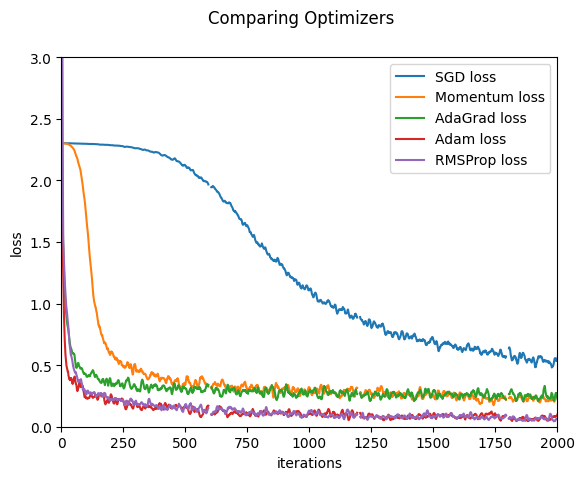

In [71]:
x = np.arange(6000)
for key, value in outputs_dict.items():
    if key.endswith('loss'):
        
        plt.plot(x, smooth_curve(value), label=key)
        plt.legend()
        i += 1
        
plt.suptitle('Comparing Optimizers')
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0,3)
plt.xlim(0,2000)

# My optimizers

In [2]:

class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]
            
            
            
class Momentum():
    def __init__(self, lr=0.01, momentum=0.9) -> None:
        self.lr = lr
        self.v = None
        self.momentum = momentum
        
    def update(self, params, grads):
        if self.v == None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
                
        for key in params.keys():
            self.v[key] = (self.momentum * self.v[key]) - (self.lr * grads[key])
            params[key] += self.v[key]
            


## AdaGrad
- weight decay가 0으로 수렴하는 문제.

In [8]:
AdaGrad_update_dict = defaultdict(list)


class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None
    
    def update(self, params, grads):
        if self.h == None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.h[key] += grads[key]**2
            
            update_value = self.lr / (np.sqrt(self.h[key]) + 1e-7) * grads[key]
            params[key] -= update_value
            
            
            print(f'{key}: {np.average(update_value)}')
            AdaGrad_update_dict[key].append(np.average(update_value))

In [9]:
train_loss_list = []
train_acc_list = []
test_acc_list = []

network = TwoLayerNet(784, [50], 10)
optimizer = AdaGrad(lr=learning_rate)

iter_idx = 0
for epoch_idx in range(1, epoch+1):
    print(f"===== {epoch_idx} epoch started =====")
    batch_mask_generator = batch_mask_loader(x_train, batch_size=100)
    
    for batch_mask in batch_mask_generator:
        
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        
        # print(x_batch.shape, t_batch.shape)
        # print('predict x batch shape', network.predict(x_batch).shape)
        
        # grads = network.numerical_gradient(x_batch, t_batch)
        grads = network.gradient(x_batch, t_batch)
        
        optimizer.update(network.params, grads)
    
        loss = network.loss(x_batch, t_batch)
        # print(f'{iter_idx} loss: {loss}')
        train_loss_list.append(loss)
        
        if iter_idx % eval_per_step == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)
            print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

        iter_idx += 1

print(f'final train acc:{network.accuracy(x_train, t_train)}')
print(f'final test acc:{network.accuracy(x_test, t_test)}') 

===== 1 epoch started =====
W1: 0.0001447126212168027
b1: -0.0007946261816156824
W2: 0.0019195492544332965
b2: -0.001998439145421996
===== train acc: 0.37448333333333333, test acc: 0.3822 =====
W1: -0.0009039311272966243
b1: -0.004523586965233663
W2: 0.0020755287566623887
b2: 0.0013210971500655709
W1: -0.00039693300209258015
b1: -0.001950025266128561
W2: 0.0007238175562881197
b2: 0.0005317326653583141
W1: -0.0009670812167825116
b1: -0.0041377450838638394
W2: 0.0012522979887868732
b2: 0.00036006708803460895
W1: -0.0003289510569419841
b1: -0.0014778063920860268
W2: 0.001260563580729451
b2: -0.0002897983287164766
W1: -0.000320260632407249
b1: -0.0020341016954299224
W2: 0.0010142687171833772
b2: 0.0005018854944006465
W1: -0.0005177496050460387
b1: -0.0016273071352803526
W2: 0.00025788677355739043
b2: -0.000181482325734322
W1: -5.190779637306957e-05
b1: -0.0011853627231368203
W2: 0.0003644114070550406
b2: -0.0003478951459595386
W1: -0.0003268021203961793
b1: -0.001882106042224444
W2: 0.0007

c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:50: RuntimeWarning: invalid value encountered in scalar divide
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size


===== train acc: 0.9161, test acc: 0.9164 =====
W1: 3.454066554603774e-06
b1: 3.1403068664656925e-05
W2: -2.078048523039058e-05
b2: -1.1937216711135464e-05
W1: -2.418620809490494e-05
b1: -7.549422624171497e-05
W2: 3.2026354245300345e-05
b2: 2.329584676427704e-05
W1: -7.565955579925475e-06
b1: -3.698850567018179e-05
W2: 4.783771112121558e-06
b2: -1.2015175427832704e-05
W1: 2.0491027230256218e-05
b1: 6.418119718953536e-05
W2: -1.029446682037007e-05
b2: -2.0572513737102913e-05
W1: -3.4791247758905874e-06
b1: -4.022529829490307e-06
W2: -9.467376023812193e-06
b2: -2.0530511790925217e-05
W1: 9.841946687805004e-06
b1: 6.29468557063508e-05
W2: 8.430410969179837e-06
b2: -1.6294587362228275e-06
W1: -2.740806351286574e-05
b1: -9.301701239021961e-05
W2: 5.829190509684409e-05
b2: 5.516814599230166e-05
W1: -1.2611295102523523e-05
b1: -2.69128570625262e-05
W2: -3.707274108790856e-06
b2: -5.017329980711651e-06
W1: 2.9695403330164412e-05
b1: 7.882305904230249e-05
W2: 5.057019806628508e-05
b2: 3.5858074

In [10]:
AdaGrad_update_dict.items()

dict_items([('W1', [0.0001447126212168027, -0.0009039311272966243, -0.00039693300209258015, -0.0009670812167825116, -0.0003289510569419841, -0.000320260632407249, -0.0005177496050460387, -5.190779637306957e-05, -0.0003268021203961793, -0.0001749295990095677, -0.00022989923293292278, -0.00012406826285214876, -0.0002506743363909376, 3.836647350246593e-05, -0.00022781173513386325, -0.00010356599508658136, -0.00020045624300520123, -0.00014486315659485634, -0.0001981445416918372, 3.4740236056296014e-05, -0.0001736686123215359, -8.532825612533083e-05, -3.8582053064813744e-05, -0.00016219577227904357, 0.0001886306969788614, -9.336814840979435e-05, -0.00010447345717119805, -0.00011514740569395815, -9.788643965533152e-06, 2.7595041476338524e-05, -0.00015677557375430964, -0.0001543162716879952, -6.700457750393118e-05, -5.9521882647158536e-05, -4.15132563566938e-05, -3.622982795147966e-05, -5.4009777307026644e-05, -9.127911152420147e-05, -4.527934383923177e-05, -5.300496998784559e-05, 1.393277230

Text(0.5, 0.98, 'AdaGrad update values')

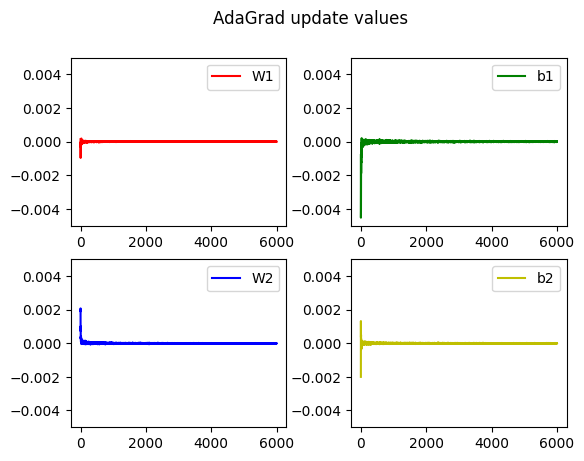

In [19]:
colors = 'rgby'
for i, (key,value) in enumerate(AdaGrad_update_dict.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(value, label=key, color=colors[i])
    plt.ylim(-0.005, 0.005)
    plt.legend()

plt.subplots_adjust(wspace=0.3)
plt.suptitle('AdaGrad update values')

## RMSProp
- https://velog.io/@cha-suyeon/DL-%EC%B5%9C%EC%A0%81%ED%99%94-%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98-RMSProp-Adam

In [12]:
RMS_update_dict = defaultdict(list)

class RMSProp:
    def __init__(self, lr=0.01, decay_rate=0.99):
        self.lr = lr
        self.h = None
        self.decay_rate = decay_rate
    
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.h[key] *= self.decay_rate
            self.h[key] += (1-self.decay_rate) * grads[key] * grads[key]
            
            update_value = self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)
            params[key] -= update_value
            
            
            
            print(f'{key}: {np.average(update_value)}')
            RMS_update_dict[key].append(np.average(update_value))

In [13]:
train_loss_list = []
train_acc_list = []
test_acc_list = []

network = TwoLayerNet(784, [50], 10)
optimizer = RMSProp(lr=learning_rate)

iter_idx = 0
for epoch_idx in range(1, epoch+1):
    print(f"===== {epoch_idx} epoch started =====")
    batch_mask_generator = batch_mask_loader(x_train, batch_size=100)
    
    for batch_mask in batch_mask_generator:
        
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        
        # print(x_batch.shape, t_batch.shape)
        # print('predict x batch shape', network.predict(x_batch).shape)
        
        # grads = network.numerical_gradient(x_batch, t_batch)
        grads = network.gradient(x_batch, t_batch)
        
        optimizer.update(network.params, grads)
    
        loss = network.loss(x_batch, t_batch)
        # print(f'{iter_idx} loss: {loss}')
        train_loss_list.append(loss)
        
        if iter_idx % eval_per_step == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)
            print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

        iter_idx += 1

print(f'final train acc:{network.accuracy(x_train, t_train)}')
print(f'final test acc:{network.accuracy(x_test, t_test)}') 

===== 1 epoch started =====
W1: -0.0008619771816024501
b1: -0.0060147155405456156
W2: 0.02061208345712226
b2: -4.090804582843055e-07
===== train acc: 0.10383333333333333, test acc: 0.1036 =====
W1: 0.01833993420810775
b1: 0.029732598726631854
W2: -0.027887823209501564
b2: -0.04213384223671564
W1: 0.012824660429121296
b1: 0.02349444000630445
W2: -0.017718881689847397
b2: -0.046388345017573794
W1: 0.004546051860320458
b1: 0.006757017342329197
W2: 0.0007028843589135726
b2: -0.009535475074136697
W1: -0.0008233322433793183
b1: -0.0014993791499921224
W2: 0.0012667687148188215
b2: 0.003645586453228093
W1: -4.291086085040611e-05
b1: 0.00143726055325022
W2: 0.0011649353673952438
b2: 0.003651610801302799
W1: -0.0004302485235688251
b1: -0.0007754904221273992
W2: 0.001471464032881549
b2: 0.0066972345200550145
W1: 0.0002001954539438141
b1: -0.0019352462267056647
W2: 0.000382574589494897
b2: 0.004020702143850854
W1: 0.0001268865183345166
b1: 0.00034943125670056975
W2: 0.000307332102741908
b2: 0.0030

Text(0.5, 0.98, 'RSMProp updae values')

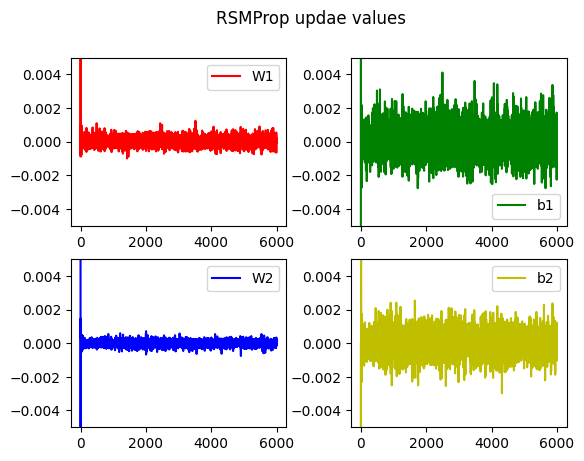

In [16]:
colors = 'rgby'
for i, (key,value) in enumerate(RMS_update_dict.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(value, label=key, color=colors[i])
    plt.ylim(-0.005, 0.005)
    plt.legend()

plt.subplots_adjust(wspace=0.3)
plt.suptitle('RSMProp updae values')

## Adam

In [274]:
class Adam():
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999) -> None:
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.m = None
        self.v = None
        self.iter = 1
    
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        for key in params.keys():        
            self.m[key] = self.beta1 * self.m[key] + ((1.0 - self.beta1) * grads[key]) 
            # self.m[key] /= (1.0 - self.beta1**self.iter)
            self.v[key] = self.beta2 * self.v[key] + ((1.0 - self.beta2) * grads[key]**2) 
            # self.v[key] /= np.sqrt(1.0 - self.beta2**self.iter)
            
            params[key] -= self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter) * self.m[key] / (np.sqrt(self.v[key]) + 1e-7) 
        
        self.iter += 1

## Comparing optimizers

In [275]:
import sys, os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from my_models import TwoLayerNet, batch_mask_loader
# from common.optimizer import *
from common.util import smooth_curve


np.random.seed(42)

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)


epoch = 10
eval_per_step = 600
train_size = x_train.shape[0]
batch_size = 200
learning_rate = 0.01

network = TwoLayerNet(784, 50, 10)

In [276]:
optimizers_dict = {
    'SGD': SGD(lr=learning_rate),
    'Momentum': Momentum(lr=learning_rate),
    'AdaGrad': AdaGrad(lr=learning_rate),
    'Adam': Adam(lr=learning_rate),
    'RMSProp': RMSProp(lr=learning_rate),
}

outputs_dict = defaultdict(list)


for key, optimizer in optimizers_dict.items():
    
    network = TwoLayerNet(784, 50, 10)
    optimizer = optimizer
    
    train_loss_list = []
    train_acc_list = []
    test_acc_list = []
    
    iter_idx = 0
    for epoch_idx in range(1, epoch+1):
        print(f"===== {epoch_idx} epoch started =====")
        batch_mask_generator = batch_mask_loader(x_train, batch_size=100)

        for batch_mask in batch_mask_generator:

            x_batch = x_train[batch_mask]
            t_batch = t_train[batch_mask]

            # print(x_batch.shape, t_batch.shape)
            # print('predict x batch shape', network.predict(x_batch).shape)

            # grads = network.numerical_gradient(x_batch, t_batch)
            grads = network.gradient(x_batch, t_batch)

            optimizer.update(network.params, grads)

            loss = network.loss(x_batch, t_batch)
            # print(f'{iter_idx} loss: {loss}')
            train_loss_list.append(loss)

            if iter_idx % eval_per_step == 0:
                train_acc = network.accuracy(x_train, t_train)
                test_acc = network.accuracy(x_test, t_test)
                train_acc_list.append(train_acc)
                test_acc_list.append(test_acc)
                print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

            iter_idx += 1
    
    outputs_dict[f'{key} loss'] = train_loss_list
    outputs_dict[f'{key} train acc'] = train_acc_list
    outputs_dict[f'{key} test acc'] = test_acc_list

    print(f'final train acc:{network.accuracy(x_train, t_train)}')
    print(f'final test acc:{network.accuracy(x_test, t_test)}') 

===== 1 epoch started =====


===== train acc: 0.1072, test acc: 0.1039 =====


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:50: RuntimeWarning: invalid value encountered in scalar divide
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size


===== 2 epoch started =====
===== train acc: 0.52, test acc: 0.52 =====
===== 3 epoch started =====
===== train acc: 0.7975166666666667, test acc: 0.8011 =====
===== 4 epoch started =====
===== train acc: 0.8484333333333334, test acc: 0.8535 =====
===== 5 epoch started =====
===== train acc: 0.87195, test acc: 0.8769 =====
===== 6 epoch started =====
===== train acc: 0.8847333333333334, test acc: 0.8882 =====
===== 7 epoch started =====
===== train acc: 0.8916166666666666, test acc: 0.8952 =====
===== 8 epoch started =====
===== train acc: 0.8963333333333333, test acc: 0.9003 =====
===== 9 epoch started =====
===== train acc: 0.90135, test acc: 0.9048 =====
===== 10 epoch started =====
===== train acc: 0.9044666666666666, test acc: 0.9076 =====
final train acc:0.9065166666666666
final test acc:0.9094
===== 1 epoch started =====
===== train acc: 0.11961666666666666, test acc: 0.1228 =====
===== 2 epoch started =====
===== train acc: 0.9037166666666666, test acc: 0.9079 =====
===== 3 epo

In [277]:
outputs_dict['Adam loss']

[2.228193238615194,
 2.0589528481613764,
 1.882875051661771,
 1.8855523600591595,
 1.6557828243430506,
 1.6263898042823484,
 1.4012596281611829,
 1.384137442820837,
 1.0351523131493394,
 0.9388331508708733,
 0.9755232476662072,
 0.749761550819531,
 0.7972864676722697,
 0.6172661801965426,
 0.7846011479301833,
 0.7279896742324296,
 0.610276784423059,
 0.5465915817926672,
 0.5152153242634098,
 0.44896193123957195,
 0.5315401239095305,
 0.37908019948816757,
 0.4398080143063411,
 0.6676685221644457,
 0.4226208382102621,
 0.5651160749905312,
 0.32319526280940264,
 0.5151980568826905,
 0.32554434664425985,
 0.4420155654708467,
 0.4082449940530347,
 0.32860300328316433,
 0.5779526577052971,
 0.3379307411650109,
 0.2781206422762248,
 0.44563918560364535,
 0.3186140041999761,
 0.30463936082147736,
 0.45719160148330373,
 0.4453961089422977,
 0.24877119903030884,
 0.6125877018909627,
 0.46001296522765195,
 0.261109852630226,
 0.41737636401167416,
 0.2728985738327124,
 0.4031433128539497,
 0.24815

(0.0, 2000.0)

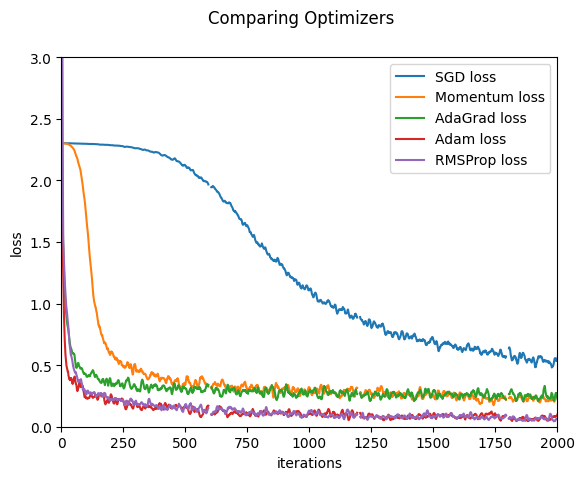

In [280]:
x = np.arange(6000)

for key, value in outputs_dict.items():
    if key.endswith('loss'):
        plt.plot(x, smooth_curve(value), label=key)
        plt.legend()
        i += 1
        
plt.suptitle('Comparing Optimizers')
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0,3)
plt.xlim(0,2000)
